<h1><center><b> DA&V (LAB_3), Data Wrangling </b></center></h1>

***INSTRUCTIONS*** <br>
You all are required to perform data wrangling and do all tasks, Every question has some sub-questions and all of them have designated code cell, Read the question carefully and write the code according to the number of question, Add comment in code section before writing code.

The dataset/s required for the lab download from Kaggle, use them according to the task.

<br>
<h1><center>GOOD LUCK, Happy Labbing :D </center></h1>

### **1. Load the dataset**



In [30]:
import pandas as pd

df1 = pd.read_csv("train.csv")
df2 = pd.read_csv("store.csv")

<ipython-input-30-b7e4843b6c7f>:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("train.csv")


### **2. Merge both datasets into 1 dataset.**
*2.1. Show first and last 5 rows of the dataset.* <br>
*2.2. Show description of the dataset.*

In [31]:
merged_df = pd.merge(df1, df2)

print(merged_df.head())
print(merged_df.tail())

merged_df.describe()

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      1          4  2015-07-30   5020        546     1      1            0   
2      1          3  2015-07-29   4782        523     1      1            0   
3      1          2  2015-07-28   5011        560     1      1            0   
4      1          1  2015-07-27   6102        612     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         c          a               1270.0   
2              1         c          a               1270.0   
3              1         c          a               1270.0   
4              1         c          a               1270.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


### **3. Dealing with Missing values**

1.   Check for the missing values
2.   Count the missing values


In [32]:
missing_values = merged_df.isnull()

In [33]:
missing_values = missing_values.sum()
missing_values

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

### **4. Handle missing values (if any)**
*4.1. Handle by mean or mode* <br>
*4.2. Remove useless column* <br>
*4.3. Check datatypes of the columns*

In [34]:
# Filling with mean for numeric columns
numeric_columns = merged_df.select_dtypes(include=['number'])
merged_df[numeric_columns.columns] = merged_df[numeric_columns.columns].fillna(merged_df.mean())

# Filling with mode for categorical columns
categorical_columns = merged_df.select_dtypes(include=['object'])
merged_df[categorical_columns.columns] = merged_df[categorical_columns.columns].fillna(merged_df.mode().iloc[0])

# Remove a useless column
merged_df = merged_df.drop(columns=['StateHoliday'])

print("Data types of columns:")
print(merged_df.dtypes)

<ipython-input-34-c9695a860619>:3: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  merged_df[numeric_columns.columns] = merged_df[numeric_columns.columns].fillna(merged_df.mean())


Data types of columns:
Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object


### **5. Encode categorical features**



1.   Label Encoding
2.   OneHot Encoding
3.   Target Encoding
4.   Binary Transformation


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

merged_df['Store_encoded'] = label_encoder.fit_transform(merged_df['Store'])
merged_df['DayOfWeek_encoded'] = label_encoder.fit_transform(merged_df['DayOfWeek'])
merged_df['Open_encoded'] = label_encoder.fit_transform(merged_df['Open'])
merged_df['Promo_encoded'] = label_encoder.fit_transform(merged_df['Promo'])
merged_df['SchoolHoliday_encoded'] = label_encoder.fit_transform(merged_df['SchoolHoliday'])
merged_df['StoreType_encoded'] = label_encoder.fit_transform(merged_df['StoreType'])
merged_df['Assortment_encoded'] = label_encoder.fit_transform(merged_df['Assortment'])

In [11]:
merged_df = pd.get_dummies(merged_df, columns=['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'StoreType', 'Assortment'])
print(merged_df.head())

         Date  Sales  Customers  CompetitionDistance  \
0  2015-07-31   5263        555               1270.0   
1  2015-07-30   5020        546               1270.0   
2  2015-07-29   4782        523               1270.0   
3  2015-07-28   5011        560               1270.0   
4  2015-07-27   6102        612               1270.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                        9.0                    2008.0       0   
2                        9.0                    2008.0       0   
3                        9.0                    2008.0       0   
4                        9.0                    2008.0       0   

   Promo2SinceWeek  Promo2SinceYear    PromoInterval  ...  Promo_1  \
0        23.269093      2011.752774  Jan,Apr,Jul,Oct  ...        1   
1        23.269093      2011.752774  Jan,Apr,Jul,Oct  ...        1   
2        23.269093      2011.752774  Jan,Apr,Jul,Oct  ..

In [60]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=["StoreType"])

train_store = encoder.fit_transform(merged_df, merged_df['Sales'])

In [61]:
train_store = pd.get_dummies(merged_df, columns=["Assortment"], drop_first=True)

### **6. Scale numerical features**


1.   Standard scaller
2.   Min Max scaller



In [40]:
from sklearn.preprocessing import StandardScaler

numeric_columns = merged_df.select_dtypes(include=['number'])

scaler = StandardScaler()

merged_df[numeric_columns.columns] = scaler.fit_transform(merged_df[numeric_columns.columns])


In [41]:
from sklearn.preprocessing import MinMaxScaler

numeric_columns = merged_df.select_dtypes(include=['number'])

scaler = MinMaxScaler()

merged_df[numeric_columns.columns] = scaler.fit_transform(merged_df[numeric_columns.columns])


### **7. Normalize dataset using normalizer**

In [42]:
from sklearn.preprocessing import Normalizer

numeric_columns = merged_df.select_dtypes(include=['number'])

normalizer = Normalizer()

merged_df[numeric_columns.columns] = normalizer.fit_transform(merged_df[numeric_columns.columns])

### **8. Outliers**

1.   Check if there are any outlier
2.   Handle outliers



In [43]:
import numpy as np

numeric_columns = merged_df.select_dtypes(include=['number'])

# Function to detect outliers using IQR
def detect_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

# Applying function to each numerical column
outliers = numeric_columns.apply(detect_outliers)

print(outliers.sum())

Store                             0
DayOfWeek                         0
Sales                         26588
Customers                     37306
Open                         176055
Promo                             0
SchoolHoliday                181721
CompetitionDistance           96451
CompetitionOpenSinceMonth     13332
CompetitionOpenSinceYear      11812
Promo2                            0
Promo2SinceWeek               94566
Promo2SinceYear              151041
dtype: int64


In [44]:
numeric_columns = merged_df.select_dtypes(include=['number'])

# Define a function to remove outliers using IQR
def remove_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Apply the remove_outliers function to each numerical column
for column in numeric_columns.columns:
    merged_df[column] = remove_outliers(merged_df[column])

### **9. Check corelation of columns and show which were most relevant**
1. Corelation matrix and answer your findings

<ipython-input-45-1721f33a00dd>:9: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = merged_df.corr()


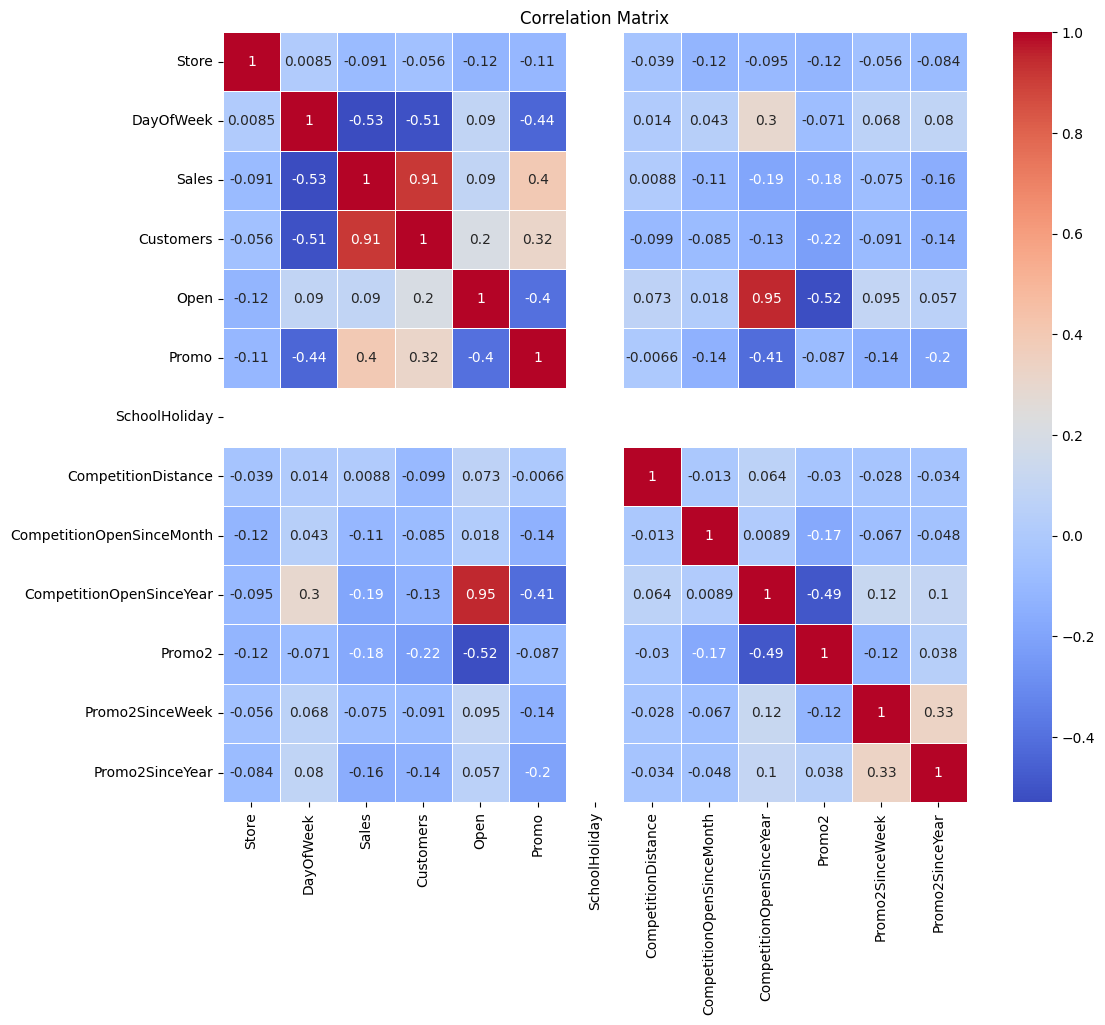

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation_matrix = merged_df.corr()

# Heatmap to visualize the correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


### **Rest of the Lab Questions**

How many unique stores are in the train_store dataframe, and what are their IDs?

In [47]:
unique_stores = merged_df['Store'].unique()
num_unique_stores = len(unique_stores)

print(f'Number of unique stores: {num_unique_stores}')
print(f'Unique store IDs: {unique_stores}')

Number of unique stores: 855401
Unique store IDs: [0.00000000e+00 3.58984267e-04 3.64816615e-04 ... 4.11196687e-01
 4.16209756e-01 4.62265015e-01]


What is the average daily sales for each store in the train_store dataframe?

In [48]:
average_daily_sales_per_store = merged_df.groupby('Store')['Sales'].mean()

print(average_daily_sales_per_store)

Store
0.000000    0.049112
0.000359    0.069002
0.000359    0.058363
0.000359    0.052318
0.000359    0.050653
              ...   
0.643836    0.000000
0.647816    0.000000
0.651308    0.000000
0.652484    0.000000
0.655696    0.000000
Name: Sales, Length: 855401, dtype: float64


How many days of data are included in the train_store dataframe, and what is the range of dates?

In [50]:
num_days = merged_df['Date'].nunique()
date_range = (merged_df['Date'].min(), merged_df['Date'].max())

print(f'Number of days of data: {num_days}')
print(f'Date range: from {date_range[0]} to {date_range[1]}')

Number of days of data: 942
Date range: from 2013-01-01 to 2015-07-31


What is the average sales per customer for each store in the train_store dataframe?

In [52]:
average_sales_per_customer_per_store = merged_df.groupby('Store').apply(lambda x: x['Sales'].sum() / x['Customers'].sum())

print(average_sales_per_customer_per_store)

Store
0.000000    1.494757
0.000359    1.717272
0.000359    1.725141
0.000359    1.558380
0.000359    1.700468
              ...   
0.643836         NaN
0.647816         NaN
0.651308         NaN
0.652484         NaN
0.655696         NaN
Length: 855401, dtype: float64


<ipython-input-52-61aecbe6ceb5>:2: RuntimeWarning: invalid value encountered in double_scalars
  average_sales_per_customer_per_store = merged_df.groupby('Store').apply(lambda x: x['Sales'].sum() / x['Customers'].sum())
<ipython-input-52-61aecbe6ceb5>:2: RuntimeWarning: divide by zero encountered in double_scalars
  average_sales_per_customer_per_store = merged_df.groupby('Store').apply(lambda x: x['Sales'].sum() / x['Customers'].sum())


Store
0.000000    1.494757
0.000359    1.717272
0.000359    1.725141
0.000359    1.558380
0.000359    1.700468
              ...   
0.643836         NaN
0.647816         NaN
0.651308         NaN
0.652484         NaN
0.655696         NaN
Length: 855401, dtype: float64


How many days of the week does each store in the train_store dataframe open and close?

In [53]:
store_open_close_days = merged_df.groupby('Store')['DayOfWeek'].unique()

print(store_open_close_days)

Store
0.000000    [0.289736456154395, 0.22144152225292557, 0.149...
0.000359                                 [0.2663611383379602]
0.000359                                [0.26660564860945435]
0.000359                                 [0.2666975733767048]
0.000359                                [0.26675261221688684]
                                  ...                        
0.643836                                [0.11068416257388425]
0.647816                                                [0.0]
0.651308                                                [0.0]
0.652484                                                [0.0]
0.655696                                                [0.0]
Name: DayOfWeek, Length: 855401, dtype: object


What is the correlation between the Sales and Customers columns in the train_store dataframe?

In [55]:
correlation = merged_df['Sales'].corr(merged_df['Customers'])

print(f'Correlation between Sales and Customers: {correlation}')

Correlation between Sales and Customers: 0.9139785115336894


## <CENTER><h1>CONGRATULATION YOU MADE IT! :D</h1></center>